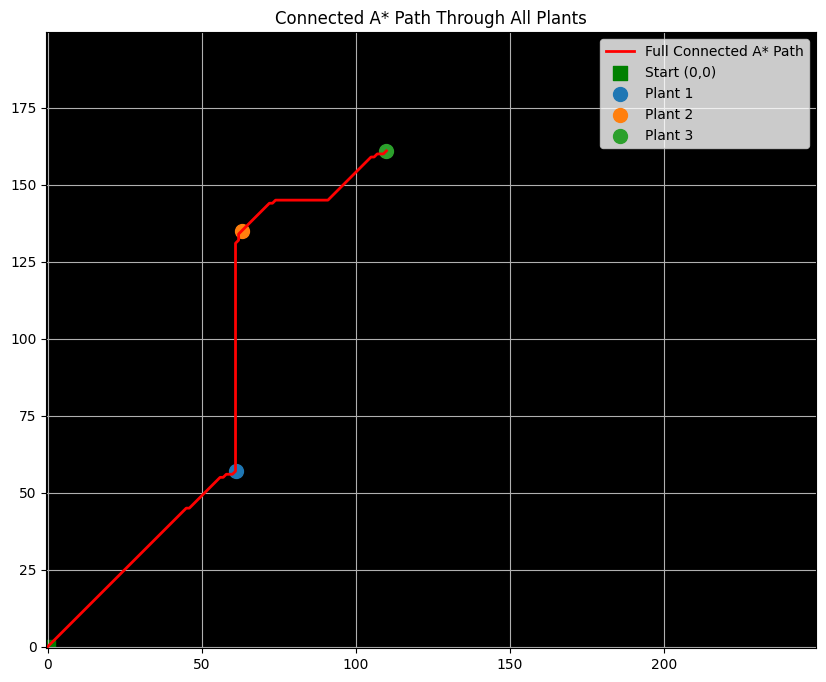

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

# Grid size
width, height = 250, 200
grid = np.zeros((height, width), dtype=np.uint8)

# Start position (y, x)
start = (0, 0)

# Ordered plant waypoints (y, x)
# You can reorder based on distance, or use TSP later
waypoints = [
    (57, 61),   # Plant 3
    (135, 63),  # Plant 1
    (161, 110)  # Plant 2
]

# 8-direction movement
moves = [(-1,  0), (1,  0), (0, -1), (0,  1),
         (-1, -1), (-1, 1), (1, -1), (1, 1)]

def heuristic(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def astar(grid, start, goal):
    height, width = grid.shape
    came_from = {}
    cost_so_far = {}
    came_from[start] = None
    cost_so_far[start] = 0
    open_list = []
    heapq.heappush(open_list, (0, start))

    while open_list:
        _, current = heapq.heappop(open_list)
        if current == goal:
            break
        for move in moves:
            neighbor = (current[0] + move[0], current[1] + move[1])
            if 0 <= neighbor[0] < height and 0 <= neighbor[1] < width:
                if grid[neighbor] == 0:
                    new_cost = cost_so_far[current] + heuristic(current, neighbor)
                    if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                        cost_so_far[neighbor] = new_cost
                        priority = new_cost + heuristic(goal, neighbor)
                        heapq.heappush(open_list, (priority, neighbor))
                        came_from[neighbor] = current

    # Reconstruct path
    path = []
    node = goal
    while node:
        path.append(node)
        node = came_from.get(node)
    path.reverse()
    return path

# Build full path by connecting each waypoint
full_path = []
current_pos = start
for wp in waypoints:
    path_segment = astar(grid, current_pos, wp)
    if full_path and path_segment:
        path_segment = path_segment[1:]  # avoid duplicate point
    full_path.extend(path_segment)
    current_pos = wp

# Plot result
plt.figure(figsize=(12, 8))
plt.imshow(grid, cmap='gray', origin='lower')

# Extract path coordinates
if full_path:
    path_y, path_x = zip(*full_path)
    plt.plot(path_x, path_y, color='red', linewidth=2, label="Full Connected A* Path")

# Plot points
plt.scatter(start[1], start[0], c='green', s=100, label='Start (0,0)', marker='s')
for i, wp in enumerate(waypoints, 1):
    plt.scatter(wp[1], wp[0], s=100, label=f'Plant {i}', marker='o')

plt.title("Connected A* Path Through All Plants")
plt.legend()
plt.grid(True)
plt.show()


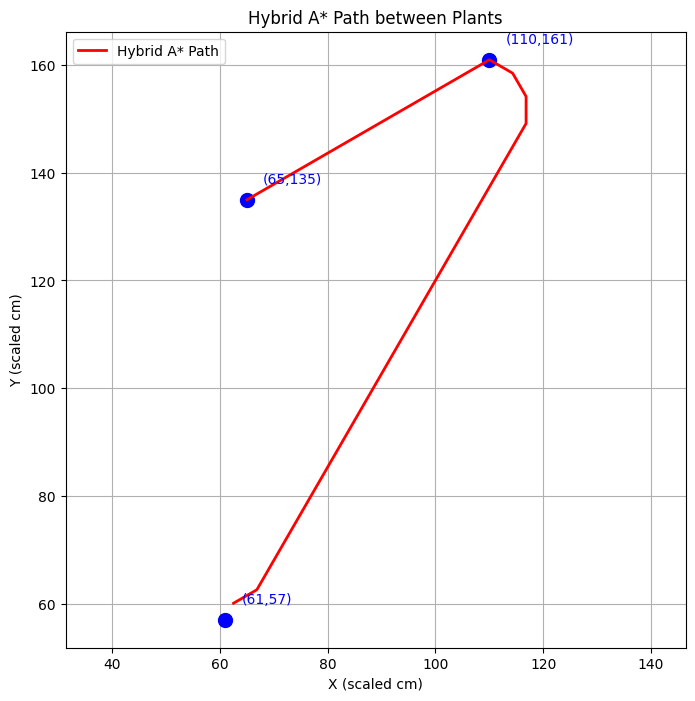

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import tan, radians, atan2, degrees, cos, sin
import heapq

# Camera parameters
fov_h = 73.74  # degrees
fov_v = 55.3   # estimated vertical FOV
img_w, img_h = 640, 480
cx, cy = img_w // 2, img_h // 2

# Plant data: (x_pixel, y_pixel, distance_in_cm)
plants_pixel_data = [
    ((242, 320), 21.6),
    ((347, 392), 19.56),
    ((216, 126), 18.25)
]

# Step 1: Convert pixel + distance to real-world X, Y
def pixel_to_world(px, py, dist_cm):
    dx = px - cx
    dy = py - cy

    x_angle = dx * (fov_h / img_w)
    y_angle = dy * (fov_v / img_h)

    X = dist_cm * tan(radians(x_angle))
    Y = dist_cm * tan(radians(y_angle))
    return X, Y

# Convert all plants to world coordinates
plant_world_coords = [pixel_to_world(x, y, d) for (x, y), d in plants_pixel_data]

# Scale up to better view (convert to mm or scale for plotting)
scale = 10  # for plotting
world_coords_scaled = [(int(x * scale + 100), int(y * scale + 100)) for x, y in plant_world_coords]

# Step 2: Hybrid A* (simplified)
class Node:
    def __init__(self, x, y, theta, cost, parent):
        self.x = x
        self.y = y
        self.theta = theta  # angle in degrees
        self.cost = cost
        self.parent = parent

    def __lt__(self, other):
        return self.cost < other.cost

def heuristic(n1, n2):
    return np.hypot(n1.x - n2.x, n1.y - n2.y)

def get_neighbors(node, step_size=5, angle_change=30):
    neighbors = []
    for d_theta in [-angle_change, 0, angle_change]:
        new_theta = node.theta + d_theta
        rad = radians(new_theta)
        new_x = node.x + step_size * cos(rad)
        new_y = node.y + step_size * sin(rad)
        neighbors.append(Node(new_x, new_y, new_theta, 0, node))
    return neighbors

def hybrid_a_star(start, goal):
    open_list = []
    visited = set()
    start_node = Node(*start, 0, None)
    goal_node = Node(*goal, 0, None)
    heapq.heappush(open_list, (0, start_node))

    while open_list:
        _, current = heapq.heappop(open_list)
        current_key = (int(current.x), int(current.y), int(current.theta) % 360)

        if current_key in visited:
            continue
        visited.add(current_key)

        if heuristic(current, goal_node) < 5:
            # Goal reached
            path = []
            while current:
                path.append((current.x, current.y))
                current = current.parent
            return path[::-1]

        for neighbor in get_neighbors(current):
            cost = current.cost + heuristic(current, neighbor)
            neighbor.cost = cost + heuristic(neighbor, goal_node)
            heapq.heappush(open_list, (neighbor.cost, neighbor))
    return []

# Step 3: Plan path through all 3 plants
path_points = []
for i in range(len(world_coords_scaled) - 1):
    start = world_coords_scaled[i]
    goal = world_coords_scaled[i + 1]
    path = hybrid_a_star((start[0], start[1], 0), (goal[0], goal[1], 0))
    path_points += path

# Step 4: Plot everything
plt.figure(figsize=(8, 8))
for (x, y) in world_coords_scaled:
    plt.plot(x, y, 'bo', markersize=10)
    plt.text(x + 3, y + 3, f'({x},{y})', color='blue')

if path_points:
    px, py = zip(*path_points)
    plt.plot(px, py, 'r-', linewidth=2, label='Hybrid A* Path')

plt.title('Hybrid A* Path between Plants')
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.xlabel('X (scaled cm)')
plt.ylabel('Y (scaled cm)')
plt.show()


In [ ]:
#Raw Coord	Actual (X, Y) in cm	Plant #	Description
(63, 135)	(-3.7, 3.5)	    Plant 1	 Left of camera,  slightly up
(110, 161)	(1.0, 6.1)	    Plant 2	 Right of camera, further up
(61, 57)	(-3.9, -4.3)	Plant 3	 Left of camera,  below center